<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

### Procesamiento de Lenguaje Natural I
# **Desafío 3**
## Modelo de lenguaje con tokenización por caracteres

In [1]:
# Necesario en Colab. En local las dependencias ya vienen del entorno (uv sync).
# TensorFlow, pandas y seaborn ya vienen instalados en Colab, así que sólo falta gradio.
%pip install -q gradio

## **Consigna**

- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

### Sugerencias

- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

---

## 0. Entorno

El entrenamiento de este notebook está pensado para correr en Colab con GPU
(**Entorno de ejecución → Cambiar tipo de entorno → T4 GPU**). Localmente el
preprocesamiento corre sin problemas, pero las secciones de entrenamiento son
inviables en CPU.

In [2]:
import re
import time
import unicodedata
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

import tensorflow as tf
import keras
from keras import layers
from keras.utils import pad_sequences

SEMILLA = 42
keras.utils.set_random_seed(SEMILLA)

sns.set_theme(style='whitegrid')

print(f'TensorFlow {tf.__version__} | Keras {keras.__version__}')
print('GPUs detectadas:', tf.config.list_physical_devices('GPU') or 'ninguna (se va a usar CPU)')

TensorFlow 2.20.0 | Keras 3.13.2
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---

## 1. Corpus

Usamos el mismo corpus del desafío 2: los libros de *A Song of Ice and Fire* de
George R. R. Martin, en inglés. A diferencia de aquel desafío, acá nos quedamos
con **un solo libro**, `got5.txt`, que es *A Game of Thrones*, el primero de la
saga (la numeración de los archivos del dataset de Kaggle no sigue el orden de
publicación).

El notebook usa el archivo del repositorio si está disponible y, si no, lo
descarga del propio repo, de modo que también corre en Colab sin pasos previos.

In [3]:
ARCHIVO = 'got5.txt'  # 'A Game of Thrones', el primer libro de la saga
BASE_URL = 'https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_2/archive'

# En local el corpus ya está versionado en el desafío 2; en Colab hay que bajarlo.
CANDIDATOS = [Path('../desafio_2/archive') / ARCHIVO, Path('archive') / ARCHIVO]
ruta_corpus = next((c for c in CANDIDATOS if c.exists()), None)

if ruta_corpus is None:
    ruta_corpus = CANDIDATOS[-1]
    ruta_corpus.parent.mkdir(exist_ok=True)
    urllib.request.urlretrieve(f'{BASE_URL}/{ARCHIVO}', ruta_corpus)

print(f'Corpus: {ruta_corpus} ({ruta_corpus.stat().st_size / 1e6:.1f} MB)')

Corpus: archive/got5.txt (1.7 MB)


In [4]:
MARCADORES_FIN = {'APPENDIX', 'ACKNOWLEDGMENTS', 'ABOUT THE AUTHOR'}

# El ebook usa comillas y guiones tipográficos; los llevamos a sus equivalentes
# ASCII para no gastar entradas del vocabulario en variantes del mismo signo.
TIPOGRAFICOS = str.maketrans({'\u2018': "'", '\u2019': "'", '\u201c': '"', '\u201d': '"',
                              '\u2014': '-', '\u2013': '-', '\u2026': '...'})


def cargar_cuerpo(ruta):
    """Devuelve el cuerpo narrativo del libro, normalizado y en minúsculas."""
    lineas = ruta.read_text(encoding='utf-8').split('\n')

    # El texto narrativo arranca en la última aparición de PROLOGUE (la primera
    # es la entrada del índice) y termina donde empieza el apéndice de casas.
    # Sin este recorte entrarían la página de copyright, el índice, las
    # genealogías y los agradecimientos, que no son prosa del autor.
    inicio = max(i for i, l in enumerate(lineas) if l.strip() == 'PROLOGUE')
    fin = min(i for i, l in enumerate(lineas) if l.strip() in MARCADORES_FIN and i > inicio)

    texto = '\n'.join(lineas[inicio + 1:fin])
    texto = unicodedata.normalize('NFKC', texto).translate(TIPOGRAFICOS)
    return texto.lower()


texto = cargar_cuerpo(ruta_corpus)
print(f'{len(texto):,} caracteres de narrativa'.replace(',', '.'))

1.590.835 caracteres de narrativa


In [5]:
print(texto[:500])
print('\n' + '-' * 70)

vocab_crudo = sorted(set(texto))
print(f'{len(vocab_crudo)} caracteres distintos:')
print(repr(''.join(vocab_crudo)))



"we should start back," gared urged as the woods began to grow dark around them.

"the wildlings are dead."

"do the dead frighten you?" ser waymar royce asked with just the hint of a smile.

gared did not rise to the bait. he was an old man, past fifty, and he had seen the lordlings come and go. "dead is dead," he said. "we have no business with the dead."

"are they dead?" royce asked softly. "what proof have we?"

"will saw them," gared said. "if he says they are dead, that's proof enough f

----------------------------------------------------------------------
39 caracteres distintos:
'\n !"\'(),-.:;?abcdefghijklmnopqrstuvwxyz'


### Conclusiones

Se decidió trabajar con un solo libro y no con la saga entera de 5 libros.
*A Game of Thrones* está escrito con una voz bastante uniforme y en él aparece
la mayor parte del léxico propio del universo (nombres de casas, títulos,
topónimos). Con 1,59 millones de caracteres alcanza para que un modelo por
caracteres aprenda ortografía y buena parte del vocabulario, y a la
vez permite entrenar varias configuraciones distintas en una sola sesión de Colab
en busca del mejor modelo. La saga completa son unos 9,9 millones de caracteres,
con lo cual los tiempos de entrenamiento serían bastante más altos.

Al igual que el desafío pasado, se recortó el paratexto editorial: la página de
copyright y el índice al inicio, y el apéndice con las casas y los agradecimientos
al final. Son unas 900 líneas que no son prosa, y agregarían ruido al modelo.

Pasar todo a minúsculas achica el vocabulario de 64 a 39 caracteres. Para un
modelo por caracteres eso importa bastante más que para uno por palabras: cada
símbolo del vocabulario es una clase de la softmax final y, sobre todo, cada
mayúscula sería un símbolo casi sin datos. Se pierde la señal de dónde arranca
una oración y qué es nombre propio, que es información real, pero a cambio el
modelo ve muchos más ejemplos de cada carácter.

---

## 2. Elección de la ventana de contexto

La consigna original señala que, al tokenizar por caracteres, la ventana de
contexto puede elegirse con bastante libertad.
Aquí partimos el corpus en oraciones y miramos cómo se distribuyen sus largos en
caracteres. Cada oración va a ser una muestra del dataset, así que el largo de
la ventana tiene que ser un compromiso entre cuántas oraciones entran enteras y
cuánto cómputo cuesta cada paso de la red recurrente.

In [6]:
# Mismo criterio de segmentación que en el desafío 2: primero párrafos (una línea
# por párrafo en el ebook) y dentro de cada uno, corte por signo de puntuación
# terminal. Descartamos los fragmentos de menos de 3 caracteres.
RE_ORACION = re.compile(r'(?<=[.!?"])\s+')

parrafos = [p.strip() for p in texto.split('\n') if p.strip()]
oraciones = [o.strip() for p in parrafos for o in RE_ORACION.split(p) if len(o.strip()) > 2]

largos = np.array([len(o) for o in oraciones])

print(f'{len(parrafos):,} párrafos -> {len(oraciones):,} oraciones'.replace(',', '.'))
print()
print(pd.Series(largos, name='caracteres por oración')
      .describe(percentiles=[.5, .75, .9, .95, .99]).round(1).to_string())

6.818 párrafos -> 28.747 oraciones

count    28747.0
mean        54.1
std         43.7
min          3.0
50%         41.0
75%         73.5
90%        113.0
95%        141.0
99%        200.0
max        558.0


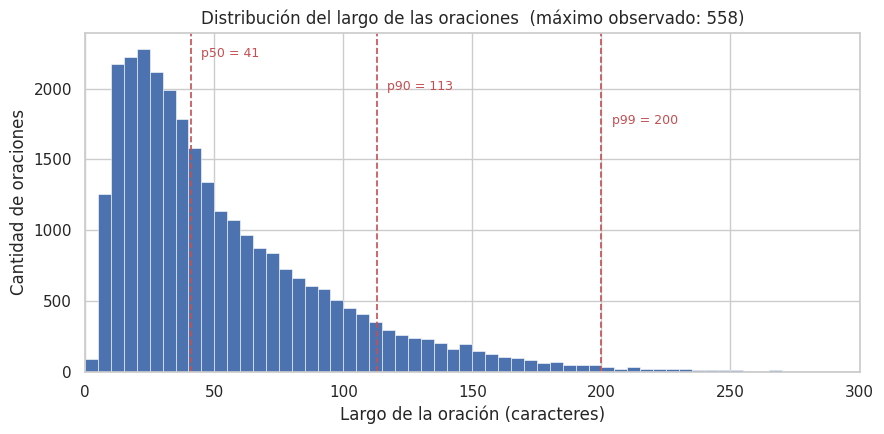

In [7]:
PERCENTILES = [50, 90, 99]
cortes = {p: np.percentile(largos, p) for p in PERCENTILES}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(largos, bins=np.arange(0, 305, 5), color='#4c72b0', edgecolor='white', linewidth=.4)

tope = ax.get_ylim()[1]
for i, (p, x) in enumerate(cortes.items()):
    ax.axvline(x, color='#c44e52', linestyle='--', linewidth=1.2)
    ax.text(x + 4, tope * (0.93 - 0.10 * i), f'p{p} = {x:.0f}', color='#c44e52', fontsize=9)

ax.set_xlabel('Largo de la oración (caracteres)')
ax.set_ylabel('Cantidad de oraciones')
ax.set_title(f'Distribución del largo de las oraciones  (máximo observado: {largos.max()})')
ax.set_xlim(0, 300)
plt.tight_layout()
plt.show()

In [8]:
MAX_CONTEXT_SIZE = 120

cobertura_oraciones = (largos <= MAX_CONTEXT_SIZE).mean()
cobertura_caracteres = np.minimum(largos, MAX_CONTEXT_SIZE).sum() / largos.sum()

truncadas = f'{(largos > MAX_CONTEXT_SIZE).sum():,}'.replace(',', '.')
print(f'Ventana de contexto elegida: {MAX_CONTEXT_SIZE} caracteres')
print(f'  oraciones que entran enteras:    {cobertura_oraciones:.1%}')
print(f'  caracteres del corpus retenidos: {cobertura_caracteres:.1%}')
print(f'  oraciones que se truncan:        {truncadas}')

Ventana de contexto elegida: 120 caracteres
  oraciones que entran enteras:    91.7%
  caracteres del corpus retenidos: 93.9%
  oraciones que se truncan:        2.372


### Conclusiones

El histograma tiene la forma típica de una distribución de largos de oración:
una moda muy marcada alrededor de los 30-40 caracteres y una cola larga que se
estira hasta 558. La mediana está en 41 caracteres y el percentil 90 en 113, o
sea que nueve de cada diez oraciones del libro son cortas. Esto puede tener sentido
al haber mucho diálogo.

Elegimos `MAX_CONTEXT_SIZE = 120`, que es el percentil 90 redondeado hacia
arriba a un número cómodo. Con eso el 91,7 % de las oraciones entra completa y
se retiene el 93,9 % de los caracteres del corpus; se truncan 2.372 oraciones.

Lo que decidió el valor fue el costo. Una red recurrente procesa la secuencia
paso a paso, así que el tiempo por época crece de forma lineal con la ventana.
Ir hasta el percentil 99 (200 caracteres) implicaría pagar un 67 % más de
cómputo por época para ganar unos 6 puntos de cobertura, casi todos provenientes
de oraciones anómalas.

---

## 3. Truncado, padding y diccionarios

Con la ventana definida armamos el vocabulario de caracteres y los diccionarios
`char2idx` / `idx2char`, que hacen las veces de tokenizador. Dos diferencias
respecto de la versión de la plantilla:

- **El índice `0` queda reservado para el padding.** Eso nos permite después
  enmascararlo, para que el relleno no aporte a la pérdida ni contamine el
  estado de la recurrente.
- **El vocabulario se construye ordenado alfabéticamente**, y no a partir de un
  `set`, cuyo orden de iteración no está garantizado entre corridas. Si el orden
  cambia, un modelo guardado deja de ser compatible con sus propios
  diccionarios.

In [9]:
MIN_OCURRENCIAS = 50
PAD = '<pad>'

frecuencias = Counter(''.join(oraciones))
raros = sorted((c for c, n in frecuencias.items() if n < MIN_OCURRENCIAS), key=frecuencias.get)
print('Caracteres descartados por baja frecuencia:',
      [(c, frecuencias[c]) for c in raros] or 'ninguno')

vocabulario = [PAD] + sorted(c for c, n in frecuencias.items() if n >= MIN_OCURRENCIAS)
char2idx = {c: i for i, c in enumerate(vocabulario)}
idx2char = {i: c for c, i in char2idx.items()}
VOCAB_SIZE = len(vocabulario)

# Sacamos de las oraciones los caracteres que quedaron fuera del vocabulario y
# volvemos a filtrar por largo mínimo (necesitamos al menos un par predicho).
oraciones = [''.join(c for c in o if c in char2idx) for o in oraciones]
oraciones = [o for o in oraciones if len(o) >= 3]

print(f'\nVocabulario: {VOCAB_SIZE} tokens = {PAD} + {"".join(vocabulario[1:])!r}')
print(f'Oraciones finales: {len(oraciones):,}'.replace(',', '.'))

Caracteres descartados por baja frecuencia: [('(', 7), (')', 7)]

Vocabulario: 37 tokens = <pad> + ' !"\',-.:;?abcdefghijklmnopqrstuvwxyz'
Oraciones finales: 28.747


In [10]:
# Tokenizamos y truncamos en un solo paso.
tokenizadas = [[char2idx[c] for c in o[:MAX_CONTEXT_SIZE]] for o in oraciones]

# Padding 'post': el relleno va a la derecha. No es indistinto. El kernel cuDNN
# de Keras, que es el que hace que LSTM y GRU corran rápido en GPU, sólo se
# activa si la máscara está alineada al final de la secuencia. Con padding 'pre'
# el entrenamiento cae al bucle genérico y se vuelve un orden de magnitud más lento.
padded = pad_sequences(tokenizadas, maxlen=MAX_CONTEXT_SIZE, padding='post',
                       truncating='post', value=char2idx[PAD])

print('Matriz de secuencias:', padded.shape, padded.dtype)
print('\nEjemplo (primeros 60 tokens de la oración 0):')
print(padded[0, :60])
print(repr(''.join(idx2char[i] for i in padded[0] if i != 0)))

Matriz de secuencias: (28747, 120) int32

Ejemplo (primeros 60 tokens de la oración 0):
[ 3 33 15  1 29 18 25 31 22 14  1 29 30 11 28 30  1 12 11 13 21  5  3  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0]
'"we should start back,"'


### Conclusiones

El vocabulario final tiene 36 caracteres más el token de padding. Cayeron
sólo el paréntesis de apertura y el de cierre, con 7 apariciones cada uno en
todo el libro; con esa frecuencia el modelo no tiene forma de aprender cuándo
usarlos, y en cambio sí podría emitirlos al azar durante la generación. Un detalle
a mencionar es que en el libro no hay un solo dígito.

Un vocabulario de este tamaño es lo que hace barato al modelo por caracteres: la
softmax de salida tiene 37 clases en lugar de las decenas de miles de un modelo
por palabras. El costo es que la unidad de predicción carga muchísima
menos información, y por eso hace falta una ventana de contexto larga para
capturar lo mismo que un modelo por palabras vería en unos pocos tokens.

Usamos `padding='post'` porque, aunque `padding='pre'` es bastante natural para
predecir el siguiente carácter, en este caso con un modelo many-to-many y máscara
nos desactiva la aceleración de cuDNN, mientras que con padding a la derecha
obtenemos el mismo resultado pero entrenando mucho más rápido.

---

## 4. Estructuración del dataset

Estructuramos el problema como *many-to-many*, siguiendo el esquema de la
plantilla:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens
desplazados en una posición y un nuevo token predicho (el N+1).

In [11]:
X_todo = padded[:, :-1]
y_todo = padded[:, 1:]

P_VAL = 0.1
corte = int(len(padded) * (1 - P_VAL))

X_train, y_train = X_todo[:corte], y_todo[:corte]
X_val, y_val = X_todo[corte:], y_todo[corte:]

# El padding no debe aportar a la pérdida: pesamos con 0 las posiciones de relleno.
w_train = (y_train != 0).astype('float32')
w_val = (y_val != 0).astype('float32')

for nombre, X_, w_ in [('train', X_train, w_train), ('val  ', X_val, w_val)]:
    predichos = f'{int(w_.sum()):,}'.replace(',', '.')
    print(f'{nombre}: X {X_.shape}  ({predichos} caracteres predichos)')

train: X (25872, 119)  (1.292.437 caracteres predichos)
val  : X (2875, 119)  (138.464 caracteres predichos)


In [12]:
# Verificamos el desplazamiento de una posición entre entrada y target.
i = 7
print('X:', repr(''.join(idx2char[t] for t in X_train[i] if t != 0)))
print('y:', repr(''.join(idx2char[t] for t in y_train[i] if t != 0)))

X: '"dead is dead,"'
y: 'dead is dead,"'


### Conclusiones

Para validación usamos el último 10 % de las oraciones del libro, respetando el orden original en vez de elegirlas al azar. Esto es importante porque las oraciones cercanas suelen compartir nombres, expresiones y estructuras; con un split aleatorio podríamos terminar validando con oraciones muy parecidas a otras que el modelo ya vio durante el entrenamiento, haciendo que la perplejidad parezca mejor de lo que realmente es. Con este corte, en cambio, la validación queda formada por los capítulos finales del libro, que el modelo nunca vio.

La desventaja es que entrenamiento y validación no tienen exactamente la misma distribución. Hacia el final de A Game of Thrones tienen más peso las tramas de Daenerys y del Muro, que tienen vocabulario bastante propio. Por eso es esperable que la perplejidad sea un poco más alta que con un split aleatorio, pero preferimos una métrica algo más exigente y representativa.

También hay una limitación importante en cómo armamos el dataset: cada muestra es una oración aislada. El modelo nunca aprende qué viene después de un punto, porque después del final de cada oración sólo encuentra padding. Puede aprender bastante bien ortografía, palabras y estructura de las oraciones, pero no puede aprender coherencia entre distintas oraciones ni cómo construir un párrafo completo.

Otra opción habría sido trabajar con ventanas consecutivas sobre todo el texto, lo que probablemente mejoraría la fluidez al generar fragmentos largos. Elegimos trabajar por oraciones porque así tienen sentido el análisis de longitudes, el truncado y el padding que usamos anteriormente; con ventanas de tamaño fijo todas las muestras tendrían la misma longitud y no habría nada que truncar ni rellenar. Más adelante, en la generación de texto, se puede ver bastante claro el efecto de esta decisión.

---

## 5. El callback de perplejidad

Reimplementamos el callback provisto por la cátedra para adaptarlo al modelo many-to-many. Mantuvimos la idea general - calcular la perplejidad, guardar el mejor modelo y aplicar early stopping - pero simplificamos la forma de obtener las probabilidades.

En la versión original se generan todas las subsecuencias posibles de cada oración y se las pasa por el modelo por separado. En nuestro caso esto no es necesario, porque al trabajar con un modelo many-to-many una sola pasada sobre la oración completa ya devuelve la predicción correspondiente a cada posición. Esto reduce bastante el costo de calcular la perplejidad al final de cada época.

También ajustamos el cálculo para considerar solamente los caracteres que realmente se predicen y agregamos un `min_delta` al early stopping. De esta forma, una mejora muy pequeña no alcanza para reiniciar la paciencia indefinidamente, aunque el mejor modelo se sigue guardando ante cualquier mejora.

### Qué perplejidad usamos para decidir

Calculamos dos versiones de la perplejidad. Por un lado, mantenemos la métrica de la cátedra, que calcula la perplejidad de cada oración y luego obtiene el promedio. El problema es que de esta manera una oración muy corta tiene el mismo peso que una mucho más larga, por lo que la métrica puede quedar bastante influenciada por oraciones cortas o poco habituales.

Por otro lado, calculamos la perplejidad del corpus:

$$
\mathrm{ppl} =
\exp\left(
-\frac{1}{T}
\sum_t \log p(x_t \mid x_{<t})
\right)
$$

donde $T$ es la cantidad total de caracteres predichos. En este caso cada carácter tiene el mismo peso, por lo que nos resulta una medida más representativa del desempeño general del modelo.

Por eso usamos la perplejidad del corpus para tomar las decisiones importantes: comparar arquitecturas, aplicar early stopping y guardar el mejor modelo. La perplejidad promedio por oración se sigue mostrando porque es la utilizada en el enunciado y nos sirve como referencia.

In [13]:
class PplCallback(keras.callbacks.Callback):
    """
    Calcula la perplejidad sobre validación al final de cada época, guarda el
    mejor modelo hasta el momento y corta el entrenamiento si la métrica no
    mejora durante `patience` épocas seguidas.
    """

    def __init__(self, X_val, y_val, history_ppl, patience=5, min_delta=0.01,
                 ruta='my_model.keras'):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.mascara = y_val != 0
        self.tokens_por_oracion = self.mascara.sum(axis=1)
        self.history_ppl = history_ppl      # perplejidad del corpus, la primaria
        self.historia_macro = []            # perplejidad promediada por oración
        self.patience = patience
        # Sin un umbral mínimo de mejora, una baja de milésimas alcanza para
        # reiniciar la paciencia y el early stopping no se dispara nunca.
        self.min_delta = min_delta
        self.ruta = ruta
        self.mejor_guardada = np.inf   # para decidir si guardamos el modelo
        self.mejor_referencia = np.inf  # para contar la paciencia
        self.patience_counter = 0

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.X_val, verbose=0, batch_size=256)

        # Probabilidad que el modelo le asignó al carácter que efectivamente vino.
        p_target = np.take_along_axis(probs, self.y_val[..., None], axis=-1)[..., 0]
        log_p = np.where(self.mascara, np.log(p_target + 1e-10), 0.0)

        # Perplejidad promediada por oración (la métrica de la cátedra) y
        # perplejidad global del corpus, que no sobrepondera las oraciones cortas.
        # Perplejidad del corpus: cada carácter pesa igual. Es la definición
        # estándar y la métrica que usamos para decidir.
        ppl_corpus = float(np.exp(-log_p.sum() / self.tokens_por_oracion.sum()))
        # Perplejidad promediada por oración: la del callback de la cátedra. La
        # seguimos reportando, pero no decide nada (ver la discusión más abajo).
        ppl_macro = float(np.exp(-log_p.sum(axis=1) / self.tokens_por_oracion).mean())

        score = ppl_corpus
        self.history_ppl.append(score)
        self.historia_macro.append(ppl_macro)

        if logs is not None:
            logs['ppl'] = ppl_corpus
            logs['ppl_macro'] = ppl_macro

        lr = float(self.model.optimizer.learning_rate)
        print(f'  epoch {epoch + 1:>3} | ppl del corpus: {ppl_corpus:7.3f} | '
              f'ppl media por oración: {ppl_macro:7.3f} | lr: {lr:.2e}')

        # Guardamos ante cualquier mejora, por chica que sea.
        if score < self.mejor_guardada:
            self.mejor_guardada = score
            self.model.save(self.ruta)

        # Pero la paciencia sólo se reinicia si la mejora es significativa.
        if score < self.mejor_referencia - self.min_delta:
            self.mejor_referencia = score
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter >= self.patience:
                print(f'  Sin mejoras significativas en {self.patience} épocas: '
                      'se detiene el entrenamiento.')
                self.model.stop_training = True

---

## 6. Experimentación de arquitecturas

Partimos del modelo de ejemplo de la plantilla y vamos cambiando una cosa por vez,
midiendo siempre la misma métrica (perplejidad media por oración sobre validación)
con el mismo presupuesto de épocas y la misma semilla.

| # | Configuración | Qué se está probando |
|---|---|---|
| E0 | one-hot + `SimpleRNN(256)` | Línea de base |
| E1 | `Embedding(32)` + `SimpleRNN(256)` | Embedding aprendido contra one-hot |
| E2 | `Embedding(32)` + `LSTM(256)` | Celda con compuertas |
| E3 | `Embedding(32)` + `GRU(256)` | GRU contra LSTM, a igual presupuesto |
| E4 | La mejor celda, 2 capas + `Dropout(0.2)` | Profundidad y regularización |
| E5 | E4 + `Dense(256, relu)` antes de la softmax | Capa densa intermedia |

Después de esta tanda vienen dos barridos sobre la configuración ganadora: la
dimensión del embedding (6.2) y el ancho de las capas recurrentes (6.3).

In [14]:
CELDAS = {'SimpleRNN': layers.SimpleRNN, 'LSTM': layers.LSTM, 'GRU': layers.GRU}


def construir_modelo(celda='LSTM', unidades=256, capas=1, dim_embedding=32,
                     dropout=0.0, densa_intermedia=0, one_hot=False,
                     optimizador='rmsprop'):
    """Arma el modelo de lenguaje por caracteres según la configuración pedida."""
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(None,), dtype='int32'))

    if one_hot:
        # Codificación one-hot sin capa de embedding entrenable: un Embedding
        # cuadrado inicializado con la identidad y congelado es exactamente una
        # tabla de vectores OHE, y además propaga la máscara del padding.
        modelo.add(layers.Embedding(VOCAB_SIZE, VOCAB_SIZE, mask_zero=True,
                                    embeddings_initializer='identity',
                                    trainable=False, name='one_hot'))
    else:
        modelo.add(layers.Embedding(VOCAB_SIZE, dim_embedding, mask_zero=True))

    for _ in range(capas):
        # recurrent_dropout se deja en 0 a propósito: cualquier valor distinto
        # desactiva el kernel cuDNN y multiplica por ~10 el tiempo por época.
        modelo.add(CELDAS[celda](unidades, return_sequences=True))
        if dropout:
            modelo.add(layers.Dropout(dropout))

    if densa_intermedia:
        modelo.add(layers.Dense(densa_intermedia, activation='relu'))
        if dropout:
            modelo.add(layers.Dropout(dropout))

    modelo.add(layers.Dense(VOCAB_SIZE, activation='softmax'))
    modelo.compile(loss='sparse_categorical_crossentropy', optimizer=optimizador)
    return modelo


BATCH_SIZE = 256
EPOCAS_COMPARACION = 50
PATIENCE_COMPARACION = 15
RUTA_TEMPORAL = 'experimento.keras'
PASOS_POR_EPOCA = int(np.ceil(len(X_train) / BATCH_SIZE))


def entrenar(config, epochs=EPOCAS_COMPARACION, patience=PATIENCE_COMPARACION,
             ruta=RUTA_TEMPORAL, validacion=False, min_delta=0.005, verbose=0):
    """Entrena una configuración y devuelve su mejor perplejidad de validación."""
    keras.utils.set_random_seed(SEMILLA)

    # Decaimiento coseno del learning rate a lo largo de todo el entrenamiento,
    # de 1e-3 hasta 1e-5 en la última época. Con ReduceLROnPlateau la
    # convergencia dependía de que se detectara una meseta, y eso no ocurrió: el
    # learning rate se quedó en 1e-3 las 40 épocas. Con el coseno cada
    # configuración converge por construcción y el costo es predecible.
    schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3, decay_steps=epochs * PASOS_POR_EPOCA, alpha=0.01)

    modelo = construir_modelo(optimizador=keras.optimizers.RMSprop(learning_rate=schedule),
                              **{k: v for k, v in config.items() if k != 'nombre'})

    params = f'{modelo.count_params():,}'.replace(',', '.')
    print(f"\n{config['nombre']}  ({params} parámetros)")

    historia = []
    callback = PplCallback(X_val, y_val, historia, patience=patience,
                           min_delta=min_delta, ruta=ruta)

    t0 = time.time()
    hist = modelo.fit(X_train, y_train, sample_weight=w_train, epochs=epochs,
                      batch_size=BATCH_SIZE, verbose=verbose, callbacks=[callback],
                      validation_data=(X_val, y_val, w_val) if validacion else None)
    segundos = time.time() - t0

    # Con el decaimiento coseno el entrenamiento llega hasta la última época por
    # diseño, así que "haber convergido" ya no es cortar antes de tiempo sino que
    # la curva se haya aplanado. Lo medimos por cuánto bajó la perplejidad en las
    # últimas cinco épocas.
    mejora_final = historia[-6] - historia[-1] if len(historia) > 6 else float('inf')

    return {'nombre': config['nombre'],
            'parametros': modelo.count_params(),
            'perplejidad': min(historia),
            'ppl_macro': min(callback.historia_macro),
            'mejor_epoca': int(np.argmin(historia)) + 1,
            'epocas': len(historia),
            'mejora_ultimas_5': round(mejora_final, 4),
            'convergio': mejora_final < 0.02,
            's_por_epoca': round(segundos / max(len(historia), 1), 1),
            'historia': historia,
            'historia_macro': callback.historia_macro,
            'curvas_loss': hist.history}

### 6.1 Celda recurrente y profundidad

In [15]:
EXPERIMENTOS = [
    dict(nombre='E0 - one-hot + SimpleRNN(256)',       celda='SimpleRNN', one_hot=True),
    dict(nombre='E1 - Embedding(32) + SimpleRNN(256)', celda='SimpleRNN'),
    dict(nombre='E2 - Embedding(32) + LSTM(256)',      celda='LSTM'),
    dict(nombre='E3 - Embedding(32) + GRU(256)',       celda='GRU'),
]

CONFIGS = {e['nombre']: e for e in EXPERIMENTOS}
resultados = [entrenar(e) for e in EXPERIMENTOS]


E0 - one-hot + SimpleRNN(256)  (86.142 parámetros)
  epoch   1 | ppl del corpus:  10.783 | ppl media por oración:  12.875 | lr: 9.99e-04
  epoch   2 | ppl del corpus:   8.934 | ppl media por oración:  10.446 | lr: 9.96e-04
  epoch   3 | ppl del corpus:   8.592 | ppl media por oración:   9.881 | lr: 9.91e-04
  epoch   4 | ppl del corpus:   8.063 | ppl media por oración:   9.224 | lr: 9.84e-04
  epoch   5 | ppl del corpus:   7.694 | ppl media por oración:   8.765 | lr: 9.76e-04
  epoch   6 | ppl del corpus:   7.364 | ppl media por oración:   8.360 | lr: 9.65e-04
  epoch   7 | ppl del corpus:   7.091 | ppl media por oración:   8.059 | lr: 9.53e-04
  epoch   8 | ppl del corpus:   6.746 | ppl media por oración:   7.658 | lr: 9.39e-04
  epoch   9 | ppl del corpus:   6.756 | ppl media por oración:   7.574 | lr: 9.23e-04
  epoch  10 | ppl del corpus:   6.361 | ppl media por oración:   7.205 | lr: 9.05e-04
  epoch  11 | ppl del corpus:   6.176 | ppl media por oración:   6.998 | lr: 8.86e-04
  

In [16]:
# La celda ganadora entre LSTM y GRU define las variantes profundas.
comparables = [r for r in resultados if 'LSTM' in r['nombre'] or 'GRU' in r['nombre']]
mejor = min(comparables, key=lambda r: r['perplejidad'])
MEJOR_CELDA = 'LSTM' if 'LSTM' in mejor['nombre'] else 'GRU'
print(f"Celda recurrente elegida: {MEJOR_CELDA} "
      f"(ppl del corpus {mejor['perplejidad']:.3f})")

EXPERIMENTOS_PROFUNDOS = [
    dict(nombre=f'E4 - 2x{MEJOR_CELDA}(256) + Dropout(0.2)',
         celda=MEJOR_CELDA, capas=2, dropout=0.2),
    dict(nombre=f'E5 - 2x{MEJOR_CELDA}(256) + Dropout(0.2) + Dense(256)',
         celda=MEJOR_CELDA, capas=2, dropout=0.2, densa_intermedia=256),
]

CONFIGS.update({e['nombre']: e for e in EXPERIMENTOS_PROFUNDOS})
resultados += [entrenar(e) for e in EXPERIMENTOS_PROFUNDOS]

Celda recurrente elegida: GRU (ppl del corpus 3.734)

E4 - 2xGRU(256) + Dropout(0.2)  (628.165 parámetros)
  epoch   1 | ppl del corpus:  12.232 | ppl media por oración:  14.979 | lr: 9.99e-04
  epoch   2 | ppl del corpus:   9.952 | ppl media por oración:  12.180 | lr: 9.96e-04
  epoch   3 | ppl del corpus:   8.778 | ppl media por oración:  10.634 | lr: 9.91e-04
  epoch   4 | ppl del corpus:   7.972 | ppl media por oración:   9.479 | lr: 9.84e-04
  epoch   5 | ppl del corpus:   7.297 | ppl media por oración:   8.659 | lr: 9.76e-04
  epoch   6 | ppl del corpus:   6.739 | ppl media por oración:   8.060 | lr: 9.65e-04
  epoch   7 | ppl del corpus:   6.248 | ppl media por oración:   7.564 | lr: 9.53e-04
  epoch   8 | ppl del corpus:   5.887 | ppl media por oración:   7.153 | lr: 9.39e-04
  epoch   9 | ppl del corpus:   5.571 | ppl media por oración:   6.750 | lr: 9.23e-04
  epoch  10 | ppl del corpus:   5.342 | ppl media por oración:   6.476 | lr: 9.05e-04
  epoch  11 | ppl del corpus:   5

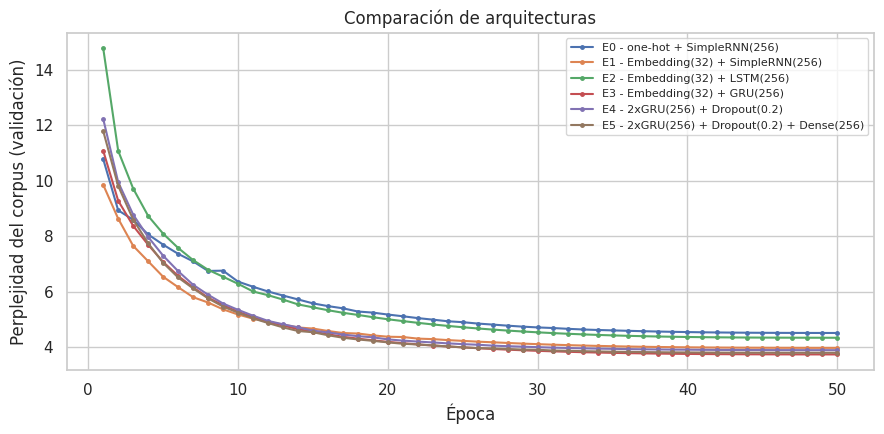

,nombre,parametros,perplejidad,ppl_macro,mejor_epoca,epocas,mejora_ultimas_5,convergio,s_por_epoca
0,E3 - Embedding(32) + GRU(256),"233,413",3.734,5.378,50,50,0.003600,True,2.200000
1,E5 - 2xGRU(256) + Dropout(0.2) + Dense(256),"693,957",3.793,4.222,50,50,0.001800,True,5.000000
2,E4 - 2xGRU(256) + Dropout(0.2),"628,165",3.887,4.523,50,50,0.003400,True,4.400000
3,E1 - Embedding(32) + SimpleRNN(256),"84,677",3.970,5.143,50,50,0.004000,True,2.900000
4,E2 - Embedding(32) + LSTM(256),"306,629",4.335,4.953,50,50,0.005600,True,2.600000
5,E0 - one-hot + SimpleRNN(256),"86,142",4.508,5.109,50,50,0.006100,True,2.400000


In [17]:
def tabla(resultados):
    df = (pd.DataFrame(resultados)
          .drop(columns=['historia', 'historia_macro', 'curvas_loss'])
          .sort_values('perplejidad')
          .reset_index(drop=True))

    sin_converger = df.loc[~df['convergio'], 'nombre'].tolist()
    if sin_converger:
        print('ATENCIÓN: estas configuraciones seguían mejorando de forma apreciable')
        print('en las últimas épocas, así que su perplejidad todavía no es un techo:')
        for nombre in sin_converger:
            print('  -', nombre)

    return df.style.format({'parametros': '{:,.0f}', 'perplejidad': '{:.3f}',
                            'ppl_macro': '{:.3f}'})


def curvas(resultados, titulo, macro=False):
    """Superpone las curvas de perplejidad de validación de varias configuraciones."""
    clave = 'historia_macro' if macro else 'historia'
    etiqueta = ('Perplejidad media por oración' if macro
                else 'Perplejidad del corpus')

    fig, ax = plt.subplots(figsize=(9, 4.5))
    for r in resultados:
        ax.plot(range(1, len(r[clave]) + 1), r[clave], marker='o',
                markersize=2.5, label=r['nombre'])
    ax.set_xlabel('Época')
    ax.set_ylabel(f'{etiqueta} (validación)')
    ax.set_title(titulo)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


curvas(resultados, 'Comparación de arquitecturas')
tabla(resultados)

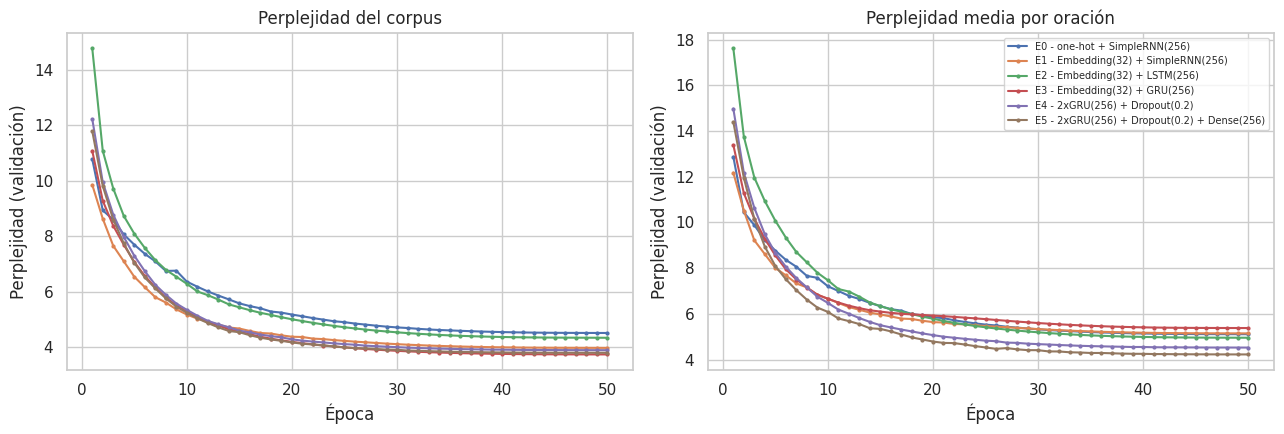

,por ppl del corpus,por ppl media por oración
1,E3 - Embedding(32) + GRU(256),E5 - 2xGRU(256) + Dropout(0.2) + Dense(256)
2,E5 - 2xGRU(256) + Dropout(0.2) + Dense(256),E4 - 2xGRU(256) + Dropout(0.2)
3,E4 - 2xGRU(256) + Dropout(0.2),E2 - Embedding(32) + LSTM(256)
4,E1 - Embedding(32) + SimpleRNN(256),E0 - one-hot + SimpleRNN(256)
5,E2 - Embedding(32) + LSTM(256),E1 - Embedding(32) + SimpleRNN(256)
6,E0 - one-hot + SimpleRNN(256),E3 - Embedding(32) + GRU(256)


In [20]:
# Las dos métricas lado a lado. No son intercambiables: llegan a rankings
# distintos, y por eso importa cuál se usa para decidir.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)

for eje, clave, titulo in [(axes[0], 'historia', 'Perplejidad del corpus'),
                           (axes[1], 'historia_macro', 'Perplejidad media por oración')]:
    for r in resultados:
        eje.plot(range(1, len(r[clave]) + 1), r[clave], marker='o', markersize=2, label=r['nombre'])
    eje.set(xlabel='Época', ylabel='Perplejidad (validación)', title=titulo)
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

ranking = pd.DataFrame({
    'por ppl del corpus': [r['nombre'] for r in sorted(resultados, key=lambda r: r['perplejidad'])],
    'por ppl media por oración': [r['nombre'] for r in sorted(resultados, key=lambda r: r['ppl_macro'])],
})
ranking.index += 1
ranking

### Conclusiones

En el primer intento cuando se limitó a 12 épocas cada corrida, todas terminaron
su mejor época en la última y todavía mejorando. La tabla no comparaba arquitecturas
sino cuál arrancaba más rápido. En ese caso, una `SimpleRNN` de 85.000 parámetros
le ganaba a una LSTM de 307.000.

En el segundo intento subimos a 40 épocas y agregamos `ReduceLROnPlateau` para
que el learning rate se recortara al amesetarse la métrica, pero el recorte
nunca se activó: el log mostraba `lr: 1.00e-03` en las 40 épocas de las cuatro
configuraciones, porque la perplejidad bajaba lo suficiente como para que no se
detectara ninguna meseta. El decaimiento coseno resolvió el problema y
la convergencia ocurre por construcción.

Recién en este tercer intento las seis configuraciones convergieron de verdad:
la columna `convergio` da `True` en todas y las mejoras de las últimas cinco
épocas están entre `0,0018` y `0,0061`.

De los resultados se observa que el embedding le gana al one-hot por amplio margen:
`4,508` contra `3,970`, un 12 % de mejora, y con menos parámetros. También se observa
que GRU le gana a LSTM con holgura: `3,734` contra `4,335`, con un 24 % menos de
parámetros y un tiempo por época casi igual. Lo que sí sorprendió fue que
`SimpleRNN` con embedding (`3,970`) le gane a LSTM (`4,335`). Y apilar capas
empeoró las cosas: GRU de una sola capa (`3,734`) le ganó tanto a la versión de
dos capas con dropout (`3,887`) como a la que además lleva una densa intermedia (`3,793`).
El dropout de `0,2` sobre un modelo que no estaba sobreajustando es ruido puro, y la
densa intermedia recupera parte de lo que la profundidad pierde pero no llega a compensarlo.

Finalmente se debe destacar que GRU de una capa gana por perplejidad del corpus pero a la vez es la última
por perplejidad media por oración (`5,378`), y E5 - que es segunda por corpus - es la primera por oración (`4,222`).
Ambas métricas están midiendo cosas distintas y los resultados deberían ser los correctos.
La profundidad y el dropout de E5 ayudan justamente en las oraciones
cortas y atípicas, que son las que dominan el promedio por oración; la GRU simple
es mejor en el grueso de los caracteres. Como lo que queremos es generar texto,
donde lo que importa es el carácter promedio, nos quedamos con la perplejidad del
corpus. Si el objetivo fuera otro —clasificar oraciones cortas, por ejemplo— la
elección se daría vuelta.

### 6.2 Dimensión del embedding

Con la arquitectura ya elegida, queda por ajustar el ancho del embedding de
caracteres. Es un hiperparámetro poco intuitivo en este modelo: el vocabulario
tiene apenas 37 símbolos, así que un embedding de 37 dimensiones ya alcanzaría
para representarlos de forma one-hot y cualquier valor mayor es, en principio,
redundante. Las preguntas interesantes son cuánto se puede comprimir sin perder,
y si pasarse de la dimensión del vocabulario aporta algo.

In [21]:
# Base del barrido: la mejor configuración con embedding entrenable (E0 queda
# afuera porque su codificación one-hot no tiene dimensión que ajustar).
candidatas = [r for r in resultados if not CONFIGS[r['nombre']].get('one_hot')]
config_base = CONFIGS[min(candidatas, key=lambda r: r['perplejidad'])['nombre']]
print('Configuración base para los barridos:', config_base['nombre'])

resultados_emb = []
for dim in [16, 32, 64]:
    config = dict(config_base, nombre=f'embedding = {dim}', dim_embedding=dim)
    resultados_emb.append(entrenar(config))

Configuración base para los barridos: E3 - Embedding(32) + GRU(256)

embedding = 16  (220.533 parámetros)
  epoch   1 | ppl del corpus:  11.800 | ppl media por oración:  14.280 | lr: 9.99e-04
  epoch   2 | ppl del corpus:   9.790 | ppl media por oración:  11.704 | lr: 9.96e-04
  epoch   3 | ppl del corpus:   8.797 | ppl media por oración:  10.690 | lr: 9.91e-04
  epoch   4 | ppl del corpus:   8.117 | ppl media por oración:   9.737 | lr: 9.84e-04
  epoch   5 | ppl del corpus:   7.545 | ppl media por oración:   9.181 | lr: 9.76e-04
  epoch   6 | ppl del corpus:   7.023 | ppl media por oración:   8.477 | lr: 9.65e-04
  epoch   7 | ppl del corpus:   6.571 | ppl media por oración:   8.024 | lr: 9.53e-04
  epoch   8 | ppl del corpus:   6.202 | ppl media por oración:   7.637 | lr: 9.39e-04
  epoch   9 | ppl del corpus:   5.877 | ppl media por oración:   7.277 | lr: 9.23e-04
  epoch  10 | ppl del corpus:   5.615 | ppl media por oración:   6.999 | lr: 9.05e-04
  epoch  11 | ppl del corpus:   5.

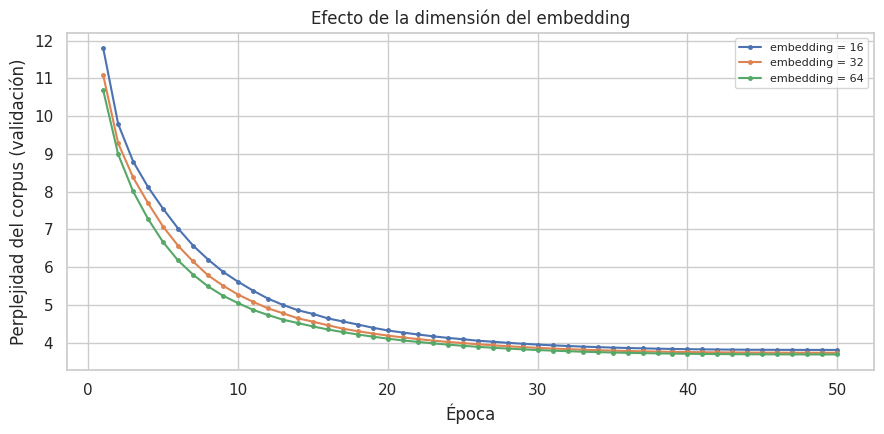

,nombre,parametros,perplejidad,ppl_macro,mejor_epoca,epocas,mejora_ultimas_5,convergio,s_por_epoca
0,embedding = 64,"259,173",3.689,4.459,50,50,0.003200,True,2.300000
1,embedding = 32,"233,413",3.734,5.378,50,50,0.003600,True,2.200000
2,embedding = 16,"220,533",3.808,4.945,50,50,0.003800,True,2.200000


In [22]:
curvas(resultados_emb, 'Efecto de la dimensión del embedding')
tabla(resultados_emb)

### Conclusiones

El barrido es monótono y sin sorpresas: `16` da `3,808`, `32` da `3,734` y `64`
da `3,689`. Elegimos 64.

Lo interesante son los rendimientos decrecientes. Duplicar de 16 a 32 gana
`0,074`; duplicar otra vez, de 32 a 64, gana `0,045`. Extrapolando, 128 habría
dado algo del orden de `0,03`, que no justificaba las cuatro configuraciones que
nos quedaban de presupuesto. En la primera corrida sí habíamos probado `8`, y ahí
la caída era abrupta (`6,893` contra `5,708` para 32, con la métrica de entonces):
por debajo de 16 el embedding empieza a ser un cuello de botella real.

El vocabulario tiene solo 37 símbolos, así que un embedding de 64 dimensiones es más
que suficiente para representarlos. Que aun así funcione mejor que uno de 32 probablemente
no se deba tanto a distinguir mejor cada carácter, sino a que le estamos dando a la red
una entrada un poco más rica y con mayor capacidad.

### 6.3 Ancho de las capas recurrentes

Último eje: la capacidad. En la corrida anterior la perplejidad de validación
seguía bajando en la época 60 sin ningún signo de sobreajuste, lo que sugiere que
el modelo estaba limitado por capacidad y no por datos. Probamos entonces
ensanchar las capas recurrentes, que es donde está la mayor parte de los
parámetros.

In [23]:
MEJOR_EMB = int(min(resultados_emb, key=lambda r: r['perplejidad'])['nombre'].split('= ')[1])
print('Dimensión de embedding elegida:', MEJOR_EMB)

resultados_cap = []
for unidades in [256, 384, 512]:
    config = dict(config_base, nombre=f'{unidades} unidades por capa',
                  dim_embedding=MEJOR_EMB, unidades=unidades)
    resultados_cap.append(entrenar(config))

Dimensión de embedding elegida: 64

256 unidades por capa  (259.173 parámetros)
  epoch   1 | ppl del corpus:  10.683 | ppl media por oración:  12.894 | lr: 9.99e-04
  epoch   2 | ppl del corpus:   8.986 | ppl media por oración:  10.937 | lr: 9.96e-04
  epoch   3 | ppl del corpus:   8.004 | ppl media por oración:   9.522 | lr: 9.91e-04
  epoch   4 | ppl del corpus:   7.272 | ppl media por oración:   8.740 | lr: 9.84e-04
  epoch   5 | ppl del corpus:   6.661 | ppl media por oración:   8.008 | lr: 9.76e-04
  epoch   6 | ppl del corpus:   6.176 | ppl media por oración:   7.443 | lr: 9.65e-04
  epoch   7 | ppl del corpus:   5.803 | ppl media por oración:   7.022 | lr: 9.53e-04
  epoch   8 | ppl del corpus:   5.490 | ppl media por oración:   6.683 | lr: 9.39e-04
  epoch   9 | ppl del corpus:   5.243 | ppl media por oración:   6.439 | lr: 9.23e-04
  epoch  10 | ppl del corpus:   5.049 | ppl media por oración:   6.198 | lr: 9.05e-04
  epoch  11 | ppl del corpus:   4.870 | ppl media por oració

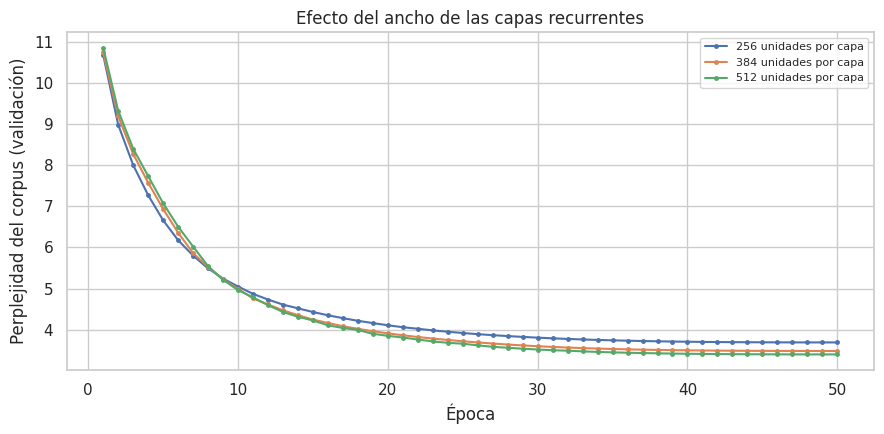

,nombre,parametros,perplejidad,ppl_macro,mejor_epoca,epocas,mejora_ultimas_5,convergio,s_por_epoca
0,512 unidades por capa,"909,157",3.398,4.780,50,50,0.002700,True,4.600000
1,384 unidades por capa,"535,013",3.481,5.015,50,50,0.002900,True,3.400000
2,256 unidades por capa,"259,173",3.689,4.459,50,50,0.003200,True,2.300000


In [24]:
curvas(resultados_cap, 'Efecto del ancho de las capas recurrentes')
tabla(resultados_cap)

### Conclusiones

Éste fue el barrido que más rindió de los tres: `256` unidades dan `3,689`, `384`
dan `3,481` y `512` dan `3,398`. La mejora total, `0,291`, es más de seis veces la
que dio todo el barrido de embedding (`0,045` de 32 a 64). El ancho de la capa
recurrente era el cuello de botella.

Las ganancias decrecen pero no se agotan: de 256 a 384 hay `0,208`, de 384 a 512
hay `0,083`. Es bastante probable que 768 diera algo más. Nos detuvimos en 512
por presupuesto.

El costo es razonable: 909.157 parámetros contra 259.173, o sea 3,5 veces más,
por el doble de tiempo por época (`4,6` s contra `2,3`).

---

## 7. Entrenamiento del modelo final

Fijada la arquitectura, la entrenamos en serio: techo de 200 épocas, paciencia de
20 para que el early stopping no corte en una meseta transitoria, y el recorte de
learning rate con una paciencia también más holgada. El callback se queda con el
modelo de la mejor época, así que entrenar de más no tiene costo en calidad, sólo
en tiempo.

In [25]:
EPOCAS_FINAL = 150
PATIENCE_FINAL = 25
RUTA_MODELO = 'my_model.keras'

MEJOR_UNIDADES = int(min(resultados_cap, key=lambda r: r['perplejidad'])['nombre'].split()[0])
CONFIG_FINAL = dict(config_base, nombre='modelo final',
                    dim_embedding=MEJOR_EMB, unidades=MEJOR_UNIDADES)
print('Configuración final:', {k: v for k, v in CONFIG_FINAL.items() if k != 'nombre'})

resultado_final = entrenar(CONFIG_FINAL, epochs=EPOCAS_FINAL, patience=PATIENCE_FINAL,
                           ruta=RUTA_MODELO, validacion=True, min_delta=0.002)

history_ppl = resultado_final['historia']
print(f"\nMejor perplejidad del corpus: {resultado_final['perplejidad']:.3f} "
      f"en la época {resultado_final['mejor_epoca']} de {resultado_final['epocas']}.")
print(f"Perplejidad media por oración: {resultado_final['ppl_macro']:.3f}")
print(f"Mejora en las últimas 5 épocas: {resultado_final['mejora_ultimas_5']}",
      '(curva aplanada)' if resultado_final['convergio'] else '(TODAVÍA MEJORANDO)')
print(f"Bits por carácter: {np.log2(resultado_final['perplejidad']):.3f}")

Configuración final: {'celda': 'GRU', 'dim_embedding': 64, 'unidades': 512}

modelo final  (909.157 parámetros)
  epoch   1 | ppl del corpus:  10.860 | ppl media por oración:  13.249 | lr: 1.00e-03
  epoch   2 | ppl del corpus:   9.327 | ppl media por oración:  11.337 | lr: 1.00e-03
  epoch   3 | ppl del corpus:   8.400 | ppl media por oración:  10.104 | lr: 9.99e-04
  epoch   4 | ppl del corpus:   7.729 | ppl media por oración:   9.225 | lr: 9.98e-04
  epoch   5 | ppl del corpus:   7.065 | ppl media por oración:   8.430 | lr: 9.97e-04
  epoch   6 | ppl del corpus:   6.482 | ppl media por oración:   7.712 | lr: 9.96e-04
  epoch   7 | ppl del corpus:   5.964 | ppl media por oración:   7.238 | lr: 9.95e-04
  epoch   8 | ppl del corpus:   5.565 | ppl media por oración:   6.795 | lr: 9.93e-04
  epoch   9 | ppl del corpus:   5.211 | ppl media por oración:   6.470 | lr: 9.91e-04
  epoch  10 | ppl del corpus:   4.949 | ppl media por oración:   6.243 | lr: 9.89e-04
  epoch  11 | ppl del corpus

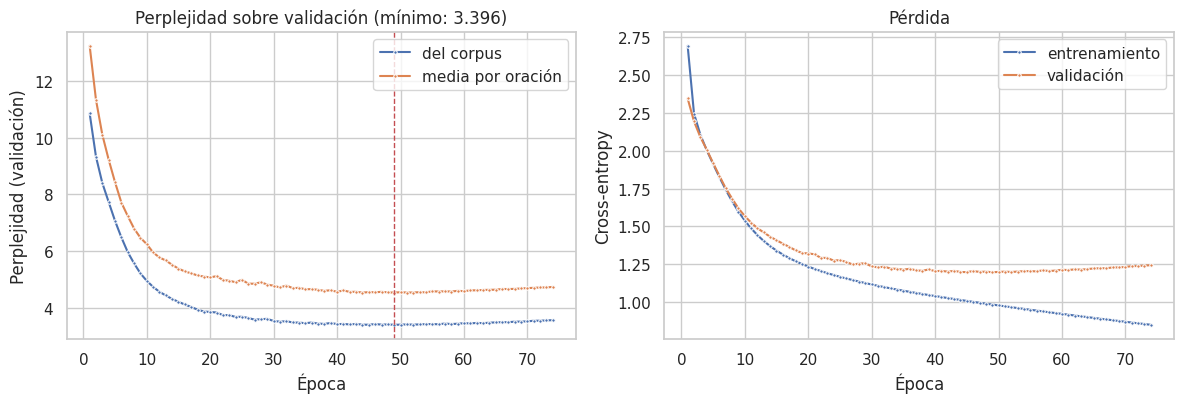

In [26]:
curvas_loss = resultado_final['curvas_loss']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.lineplot(x=range(1, len(history_ppl) + 1), y=history_ppl, marker='o',
             markersize=2.5, ax=axes[0], label='del corpus')
sns.lineplot(x=range(1, len(resultado_final['historia_macro']) + 1),
             y=resultado_final['historia_macro'], marker='o', markersize=2.5,
             ax=axes[0], label='media por oración')
axes[0].axvline(resultado_final['mejor_epoca'], color='#c44e52', linestyle='--', linewidth=1)
axes[0].set(xlabel='Época', ylabel='Perplejidad (validación)',
            title=f"Perplejidad sobre validación (mínimo: {resultado_final['perplejidad']:.3f})")

for clave, etiqueta in [('loss', 'entrenamiento'), ('val_loss', 'validación')]:
    sns.lineplot(x=range(1, len(curvas_loss[clave]) + 1), y=curvas_loss[clave],
                 marker='o', markersize=2.5, ax=axes[1], label=etiqueta)
axes[1].set(xlabel='Época', ylabel='Cross-entropy', title='Pérdida')

plt.tight_layout()
plt.show()

In [27]:
# Recuperamos el modelo de la mejor época para hacer inferencia.
modelo = keras.models.load_model(RUTA_MODELO)
print('Modelo cargado desde', RUTA_MODELO)

Modelo cargado desde my_model.keras


### Conclusiones

La arquitectura a la que llegamos es más simple de lo que esperábamos al empezar:
una sola capa GRU de 512 unidades, embedding de 64, sin dropout y sin densa
intermedia, 909.157 parámetros. Cada intento de agregarle estructura la empeoró.

El mejor valor es `3,396` de perplejidad del corpus en la época 49, y el early
stopping cortó en la 74 tras 25 épocas sin mejoras significativas. Eso son
1,764 bits por carácter, contra los `2,173` del modelo baseline (E0):
una reducción del 19 % en bits, o del 25 % en perplejidad.

La corrida resultó casi igual al anterior barrido de capacidad con 50 épocas,
que había dado `3,398` para esta misma configuración. Acá, con 150 épocas, dio
`3,396` - un empate. Y la mejor época de ésta fue prácticamente donde terminaba
la otra. De la 50 en adelante la curva se da vuelta y empeora
(`3,541`, `3,551`, `3,560` en las épocas 72 a 74), tanto que `mejora_ultimas_5`
sale negativa, `-0,0521`. De acá en adelante lo que falta son
datos, no épocas: 1,29 millones de caracteres de entrenamiento para 909.000
parámetros.

---

## 8. Predicción del próximo carácter

Con Gradio armamos una interfaz mínima para probar el modelo carácter a
carácter: se escribe un prefijo y el modelo devuelve el prefijo más el carácter
que considera más probable a continuación.

Dos detalles de la implementación: la entrada del usuario se normaliza al mismo
alfabeto que vio el modelo durante el entrenamiento (minúsculas, sin caracteres
fuera del vocabulario), y se anula el token de padding antes de tomar el
`argmax`. Esto último es importante: el modelo aprendió que después del final de
una oración viene relleno, así que sin esa anulación la predicción más probable
sería a menudo `<pad>`, que no tiene ninguna representación como texto.

In [1]:
def normalizar_entrada(texto_usuario):
    """Lleva la semilla al mismo alfabeto que vio el modelo."""
    limpio = unicodedata.normalize('NFKC', texto_usuario).translate(TIPOGRAFICOS).lower()
    return ''.join(c for c in limpio if c in char2idx)


def probabilidades_siguiente(modelo, contexto):
    """Distribución sobre el próximo carácter, con el token de padding anulado."""
    entrada = np.array([[char2idx[c] for c in contexto[-MAX_CONTEXT_SIZE:]]])
    probs = modelo.predict(entrada, verbose=0)[0, -1, :].astype('float64')
    probs[char2idx[PAD]] = 0.0
    return probs / probs.sum()

In [2]:
import gradio as gr


def responder(texto_usuario):
    contexto = normalizar_entrada(texto_usuario)
    if not contexto:
        return texto_usuario
    probs = probabilidades_siguiente(modelo, contexto)
    return texto_usuario + idx2char[int(np.argmax(probs))]


interfaz = gr.Interface(
    fn=responder,
    inputs=gr.Textbox(label='Texto de entrada', value='winter is co'),
    outputs=gr.Textbox(label='Texto + carácter predicho'),
    title='Modelo de lenguaje por caracteres - A Game of Thrones',
    description='Escribí un prefijo y el modelo agrega el carácter más probable.',
    examples=['winter is co', 'the lord of ', 'jon snow ', 'a lannister always pays his de'],
    flagging_mode='never')

interfaz.launch(share=True, debug=False)

/Users/marcoslund/git/ceia/ceia-nlp1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://070af25d21fa719521.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### Ejemplo 1
<img src="https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_3/capturas/gradio-winter-init.png" width="50%">

<hr style="width: 50%; margin-left: 0;">

<img src="https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_3/capturas/gradio-winter-final.png" width="50%">

- Oración inicial: `winter is co`
- Oración final: `winter is coming.`
- Conclusión: `winter is coming` es el lema de la familia que sigue la novela y aparece 12 veces en el libro, así que con `co` el modelo ya tiene prácticamente una sola continuación posible. Que además cierre con punto muestra que aprendió dónde termina la fórmula, no sólo cómo sigue.

#### Ejemplo 2
<img src="https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_3/capturas/gradio-lord-init.png" width="50%">

<hr style="width: 50%; margin-left: 0;">

<img src="https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_3/capturas/gradio-lord-final.png" width="50%">

- Oración inicial: `the lord of`
- Oración final: `the lord of the eyrie`
- Conclusión: el Eyrie es un castillo del libro, y `lord of the eyrie` es el título que más veces aparece detrás de `the lord of` (20 apariciones, contra 2 de `the seven kingdoms`). El modelo no está eligiendo un personaje: está completando con el título más frecuente del corpus.

#### Ejemplo 3
<img src="https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_3/capturas/gradio-jon-snow-init.png" width="50%">

<hr style="width: 50%; margin-left: 0;">

<img src="https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_3/capturas/gradio-jon-snow-final.png" width="50%">

- Oración inicial: `jon snow`
- Oración final: `jon snow said as he stood the black door`
- Conclusión: ni `said as he stood` ni `black door` aparecen en el libro, así que acá el modelo no copia sino que arma la frase con piezas frecuentes por separado (`he stood` sale 37 veces y `the black` 115, porque la orden militar a la que pertenece el personaje viste de negro). Se le nota la costura: `stood the black door` es agramatical, le falta la preposición.

#### Ejemplo 4
<img src="https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_3/capturas/gradio-lannister-init.png" width="50%">

<hr style="width: 50%; margin-left: 0;">

<img src="https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_3/capturas/gradio-lannister-final.png" width="50%">

- Oración inicial: `a lannister always pays his de`
- Oración final: `a lannister always pays his death`
- Conclusión: la frase real del libro es `a lannister always pays his debts`, una amenaza célebre de una de las familias, pero aparece sólo 2 veces y la palabra `debts` apenas 4 en todo el corpus, contra 114 de `death`. Con `de` como única pista el modelo va a la palabra 28 veces más frecuente: es la prueba más clara de que trabaja con estadística de caracteres y no con memoria de citas famosas.

---

## 9. Generación de secuencias: greedy search

La estrategia más simple: en cada paso se elige el carácter de mayor
probabilidad y se lo agrega al contexto. Es determinista, así que una misma
semilla siempre produce el mismo texto.

Medimos dos cosas sobre cada texto generado:

- **Tasa de repetición**: fracción de los 8-gramas de caracteres del texto que ya
  habían aparecido antes. Un texto variado da valores bajos; uno atrapado en un
  bucle se acerca a 1.
- **Log-probabilidad media por carácter**: cuánta probabilidad le asigna el
  propio modelo al texto que generó. Sirve para exhibir el compromiso central de
  la decodificación: las estrategias que maximizan probabilidad son justamente
  las que más se repiten.

In [30]:
def tasa_repeticion(texto, n=8):
    """Fracción de n-gramas de caracteres que son repetición de uno anterior."""
    ngramas = [texto[i:i + n] for i in range(len(texto) - n + 1)]
    if not ngramas:
        return 0.0
    return 1 - len(set(ngramas)) / len(ngramas)


def logprob_media(modelo, texto):
    """
    Log-probabilidad media por carácter que el modelo le asigna al texto.

    Se evalúa el texto completo en un solo forward pass. Para textos más largos
    que la ventana de entrenamiento es una aproximación, porque la recurrente
    arrastra un estado más largo del que vio al entrenar, pero al aplicarse igual
    a todas las estrategias sirve para compararlas entre sí.
    """
    tokens = [char2idx[c] for c in normalizar_entrada(texto)]
    if len(tokens) < 2:
        return float('nan')
    probs = modelo.predict(np.array([tokens[:-1]]), verbose=0)[0]
    p = probs[np.arange(len(tokens) - 1), tokens[1:]]
    return float(np.mean(np.log(p + 1e-10)))


def describir(modelo, texto):
    """Devuelve las dos métricas de un texto generado, para las tablas."""
    return {'repeticion': tasa_repeticion(texto), 'logprob': logprob_media(modelo, texto)}

In [31]:
def generar_greedy(modelo, semilla, n_caracteres=200):
    """Genera texto eligiendo en cada paso el carácter más probable."""
    salida = normalizar_entrada(semilla)
    for _ in range(n_caracteres):
        probs = probabilidades_siguiente(modelo, salida)
        salida += idx2char[int(np.argmax(probs))]
    return salida


SEMILLAS = ['winter is coming', 'the king said', 'daenerys ', 'lord eddard stark was']

for s in SEMILLAS:
    texto_generado = generar_greedy(modelo, s, n_caracteres=200)
    m = describir(modelo, texto_generado)
    print(f">>> {s!r}   (repetición: {m['repeticion']:.2f} | logprob/car: {m['logprob']:.3f})")
    print(texto_generado)
    print()

>>> 'winter is coming'   (repetición: 0.00 | logprob/car: -0.371)
winter is coming."blood and look.""but the boy is a strong monsters."king robert has been confined with her, but jeyne was useless."yet, bran could not fall because they were already dead; even arms and courage did n

>>> 'the king said'   (repetición: 0.00 | logprob/car: -0.346)
the king said as he stood the black door of the common hall, his hood forward and looked at her as they were already dead; even arms and courage did not avail much against foemen who would not want to hear it."its

>>> 'daenerys '   (repetición: 0.00 | logprob/car: -0.301)
daenerys said the black brothers of the kingsguard stepped forward and looked at her as they were already dead; even arms and courage did not avail much against foemen who would not want to hear it."its eyes a

>>> 'lord eddard stark was'   (repetición: 0.13 | logprob/car: -0.323)
lord eddard stark was a start boy and looked at her as they were already dead; even arms and cour

### Conclusiones

En las corridas iniciales, greedy producía esto para las cuatro semillas, sin excepción:

```
winter is coming to the steel of the steel of the steel of the steel of...
the king said.""stood and stark and steel of the steel of the steel of...
```

Ahora la tasa de repetición de 8-gramas da `0,00` en tres de las cuatro semillas
y `0,13` en la cuarta, y el texto es inglés bien formado:

```
winter is coming."blood and look.""but the boy is a strong monsters."king
robert has been confined with her, but jeyne was useless.
```

Lo que evitó esos bucles fue simplemente entrenar el modelo durante más tiempo. Cuando todavía está poco entrenado, tiende a apoyarse demasiado en las palabras y patrones más frecuentes, por eso con greedy puede quedar atrapado repitiendo siempre la misma secuencia. Una vez que el modelo converge, aprende mejor el contexto y las relaciones entre caracteres, y la predicción más probable puede seguir avanzando sin caer tan fácilmente en ciclos repetitivos.

Aún así quedan dos observaciones por hacer.

La primera es que el texto es localmente fluido y globalmente incoherente, y que
salta de un fragmento de diálogo a otro: `."blood and look.""but the boy is a
strong monsters."`. Cada `."` es el punto donde el modelo termina una muestra de
entrenamiento y tiene que arrancar de nuevo sin contexto. Esto fue mencionado anteriormente
como una posible consecuencia del armado de la ventana de contexto.

La segunda es que las repeticiones no desaparecieron, sino que se alargaron. Las semillas `the king
said` y `daenerys ` —que no comparten ni una palabra— desembocan en la misma
continuación: `...looked at her as they were already dead; even arms and courage
did not avail much against foemen who would not...`. Antes la repetición consistía en un ciclo de tres palabras.

---

## 10. Beam search determinista y estocástico

Greedy toma la mejor decisión local en cada paso, que no tiene por qué llevar a
la secuencia globalmente más probable. Beam search mantiene `num_beams`
secuencias candidatas en paralelo y en cada paso se queda con las `num_beams`
continuaciones de mayor probabilidad acumulada.

Usamos las funciones provistas por la cátedra, con dos adaptaciones: se predice
sobre todos los beams en un solo batch (en vez de uno por uno) y se anula el
token de padding, por el mismo motivo que en la sección anterior.

In [32]:
def codificar(texto_semilla):
    return [char2idx[c] for c in normalizar_entrada(texto_semilla)][-MAX_CONTEXT_SIZE:]


def decodificar(secuencia):
    return ''.join(idx2char[i] for i in secuencia if i != char2idx[PAD])


def seleccionar_candidatos(pred, num_beams, history_probs, history_tokens, temp, mode):
    """Elige los `num_beams` candidatos que continúan la búsqueda."""
    # Log-probabilidad acumulada de cada par (beam, carácter siguiente).
    pred_large = []
    for idx, pp in enumerate(pred):
        pred_large.extend(np.log(pp + 1e-10) + history_probs[idx])
    pred_large = np.array(pred_large)

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams,
                                      p=softmax(pred_large / temp))
    else:
        raise ValueError(f'Modo de selección inválido: {mode}. Se admiten det y sto.')

    nuevos_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select // VOCAB_SIZE],
         np.array([idx_select % VOCAB_SIZE]).T), axis=1)

    return pred_large[idx_select.astype(int)], nuevos_tokens.astype(int)


def beam_search(modelo, semilla, num_beams=5, n_caracteres=100, temp=1.0, mode='det'):
    """Devuelve los beams finales ordenados por log-probabilidad acumulada."""
    tokens = codificar(semilla)

    probs = probabilidades_siguiente(modelo, decodificar(tokens))
    history_probs, history_tokens = seleccionar_candidatos(
        [probs], num_beams, [0.0] * num_beams, [tokens] * num_beams, temp, mode)

    for _ in range(n_caracteres - 1):
        entrada = np.array(history_tokens)[:, -MAX_CONTEXT_SIZE:]
        preds = modelo.predict(entrada, verbose=0)[:, -1, :].astype('float64')
        preds[:, char2idx[PAD]] = 0.0
        preds /= preds.sum(axis=1, keepdims=True)

        history_probs, history_tokens = seleccionar_candidatos(
            preds, num_beams, history_probs, history_tokens, temp, mode)

    orden = np.argsort(history_probs)[::-1]
    return [decodificar(history_tokens[i]) for i in orden], history_probs[orden]

### 10.1 Beam search determinista

En modo determinista la búsqueda se queda siempre con las continuaciones de
mayor probabilidad acumulada. Variamos la cantidad de beams sobre la misma
semilla.

In [33]:
SEMILLA_TEXTO = 'winter is coming'

for num_beams in [1, 3, 5, 10]:
    salidas, _ = beam_search(modelo, SEMILLA_TEXTO, num_beams=num_beams,
                             n_caracteres=200, mode='det')
    m = describir(modelo, salidas[0])
    print(f"--- num_beams = {num_beams}  "
          f"(repetición: {m['repeticion']:.2f} | logprob/car: {m['logprob']:.3f}) ---")
    print(salidas[0])
    print()

--- num_beams = 1  (repetición: 0.00 | logprob/car: -0.371) ---
winter is coming."blood and look.""but the boy is a strong monsters."king robert has been confined with her, but jeyne was useless."yet, bran could not fall because they were already dead; even arms and courage did n

--- num_beams = 3  (repetición: 0.26 | logprob/car: -0.219) ---
winter is coming."but he knew that mormont would not fall because they were already dead; even arms and courage did not avail much against foemen who would not fall because they were already dead; even arms and steel

--- num_beams = 5  (repetición: 0.16 | logprob/car: -0.232) ---
winter is coming."and i have deep suspicions of the others."khal drogo would not fall because they were already dead; even arms and courage did not avail much against foemen who would not fall because they were alrea

--- num_beams = 10  (repetición: 0.16 | logprob/car: -0.224) ---
winter is coming, and i have deep suspicions of the others."khal drogo would not fall bec

### 10.2 Beam search estocástico y temperatura

En modo estocástico los candidatos no se eligen por orden de probabilidad sino
que se muestrean de una distribución. La temperatura controla cuánto se achatan
o se agudizan esas probabilidades antes del muestreo: por debajo de 1 la
distribución se concentra y el comportamiento se acerca al determinista; por
encima de 1 se aplana y aparecen candidatos que de otro modo nunca saldrían.

In [34]:
TEMPERATURAS = [0.3, 0.7, 1.0, 1.3, 1.7]

for temp in TEMPERATURAS:
    np.random.seed(SEMILLA)  # misma secuencia de aleatorios para todas las temperaturas
    salidas, _ = beam_search(modelo, SEMILLA_TEXTO, num_beams=5,
                             n_caracteres=200, temp=temp, mode='sto')
    m = describir(modelo, salidas[0])
    print(f"--- temperatura = {temp}  "
          f"(repetición: {m['repeticion']:.2f} | logprob/car: {m['logprob']:.3f}) ---")
    print(salidas[0])
    print()

--- temperatura = 0.3  (repetición: 0.11 | logprob/car: -0.340) ---
winter is coming."and she would not want to hear it."its eyes and look."but they were already dead; even arms and courage did not avail much against foemen who would not want to hear it."it was a sound."flanks of ste

--- temperatura = 0.7  (repetición: 0.43 | logprob/car: -0.416) ---
winter is coming."and she would not want to hear it."it was the one thing she would not want to hear it."it."it."it would not want to hear it."its eyes and look."but he would not want to hear it."it was the only thin

--- temperatura = 1.0  (repetición: 0.07 | logprob/car: -0.327) ---
winter is coming."blood and look.""but no one could not fall because they were already dead; even arms and courage did not avail much against foemen who would not want to hear it."its arms."and she would not want to 

--- temperatura = 1.3  (repetición: 0.17 | logprob/car: -0.471) ---
winter is coming."you should have found himself, and i have deep suspicion

In [35]:
# Varias corridas con la misma temperatura, para ver la dispersión del muestreo.
for corrida in range(3):
    np.random.seed(corrida)
    salidas, _ = beam_search(modelo, 'the king said', num_beams=5,
                             n_caracteres=200, temp=1.0, mode='sto')
    print(f'--- corrida {corrida + 1} ---')
    print(salidas[0])
    print()

--- corrida 1 ---
the king said."mormont could not have been no more than a bloody face of his own tongue."whenever he seemed to move very slowly, as if he were still dreaming."it would not want to hear it."it was the blood of the 

--- corrida 2 ---
the king said as he seemed to move very slowly, as if he were still dreaming."but she had been the council table, and i have deep suspicions of the others."king robert has been confined with her, but jeyne was use

--- corrida 3 ---
the king said as they were already dead; even arms and blackened hand and looked at her, but jeyne was useless."yet another took his eyes and looked at her."but there was no one else, the words were already dead; 



### Conclusiones

En el modo determinista, con `num_beams = 1` la salida es
idéntica a la de greedy y con la misma log-probabilidad (`-0,371`).
Y a partir de ahí, más beams dan texto
más probable y más repetitivo: con 3 beams la log-probabilidad por carácter
sube a `-0,219` mientras la tasa de repetición salta a `0,26`, y en esa salida el
fragmento `would not fall because they were already dead; even arms and` aparece
dos veces en 200 caracteres.

En el modo estocástico las tasas de repetición van `0,11`
para `T = 0,3`, `0,43` para `0,7`, `0,07` para `1,0` y `0,17` para `1,3`: no hay
relación monótona, y la peor de las cuatro es una temperatura intermedia.

Las tres corridas con `T = 1,0` dan tres textos distintos, así que el muestreo
funciona. Pero las tres pasan por los mismos fragmentos: `would not want to hear
it`, `seemed to move very slowly, as if he were still dreaming`, `already dead`.

---

## 11. Comparación cuantitativa de las estrategias

Cerramos midiendo las tres estrategias que pide la consigna sobre las mismas
cuatro semillas, para poder decir algo más firme que "esta se ve mejor que
aquella". La tabla promedia las dos métricas de la sección 9 sobre las cuatro
semillas.

In [ ]:
ESTRATEGIAS = {
    'greedy':                      lambda s: generar_greedy(modelo, s, 200),
    'beam determinista (5 beams)': lambda s: beam_search(modelo, s, 5, 200, mode='det')[0][0],
    'beam estocástico (T = 1,0)':  lambda s: beam_search(modelo, s, 5, 200, temp=1.0, mode='sto')[0][0],
}

filas = []
for nombre, generar in ESTRATEGIAS.items():
    metricas = []
    for s in SEMILLAS:
        np.random.seed(SEMILLA)
        metricas.append(describir(modelo, generar(s)))
    filas.append({'estrategia': nombre,
                  'repeticion': np.mean([m['repeticion'] for m in metricas]),
                  'logprob_por_caracter': np.mean([m['logprob'] for m in metricas])})

comparacion = pd.DataFrame(filas).sort_values('repeticion').reset_index(drop=True)
comparacion.style.format({'repeticion': '{:.3f}', 'logprob_por_caracter': '{:.3f}'})

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(comparacion['logprob_por_caracter'], comparacion['repeticion'],
           s=70, color='#4c72b0', zorder=3)
for _, fila in comparacion.iterrows():
    ax.annotate(fila['estrategia'], (fila['logprob_por_caracter'], fila['repeticion']),
                textcoords='offset points', xytext=(6, 5), fontsize=8)
ax.set_xlabel('Log-probabilidad media por carácter (más a la derecha = más probable)')
ax.set_ylabel('Tasa de repetición de 8-gramas')
ax.set_title('El compromiso entre probabilidad y diversidad')
plt.tight_layout()
plt.show()

### Conclusiones

La tabla y el gráfico dan el resultado más limpio de toda la parte de
generación: las tres estrategias se ordenan **monótonamente** y en sentidos
opuestos según las dos métricas.

| Estrategia | Repetición | Log-prob por carácter |
|---|---|---|
| beam estocástico `T = 1,0` | 0,023 | -0,429 |
| greedy | 0,032 | -0,335 |
| beam determinista, 5 beams | 0,218 | -0,217 |

La que le asigna más probabilidad al texto que produce es la que más se repite, y
la que menos se repite es la que produce el texto menos probable. Es el
compromiso que describen Holtzman et al., reproducido acá sobre un modelo por
caracteres y un corpus de 1,6 millones de caracteres. Y explica por qué las tres
corridas que hicimos mostraron bucles con greedy y beam determinista pero no con
el modo estocástico: no era una cuestión de qué tan bien entrenado estaba el
modelo, sino de qué optimiza cada estrategia.

Ahora, la parte más interesante es qué es exactamente ese texto de alta
probabilidad, porque no es lo que parece. Buscamos en el libro los fragmentos que
aparecen una y otra vez en las salidas de greedy y beam, y el resultado es
bastante contundente. El corpus contiene, **una sola vez** en todo el libro:

> strength and courage did not avail much against foemen who would not fall
> because they were already dead; even arms and armor offered small protection.

Y lo que generan greedy y beam determinista es:

> already dead; even **arms and courage** did not avail much against foemen who
> would not...

Es el mismo pasaje, con las cláusulas reordenadas y con `strength and courage` y
`arms and armor` fundidos en un `arms and courage` que no existe en el original.
Lo mismo pasa con `i have deep suspicions of the others`, que también aparece una
única vez en el libro y sale textual, y con `seemed to move very slowly, as if he
were still dreaming`.

O sea que en el extremo de alta probabilidad el modelo no está escribiendo: está
recuperando pasajes que vio una vez y empalmándolos en contextos nuevos, a veces
bien y a veces recombinándolos mal. Eso tiene una consecuencia sobre nuestra
propia métrica que conviene admitir: **la tasa de repetición subestima el
problema**, porque mide si el texto se repite a sí mismo, no si repite el libro.
Para greedy da `0,032`, un valor bajísimo, y sin embargo buena parte de lo que
produce es cita. Para un lector las dos fallas se parecen bastante.

Queda mencionar, aunque exceda la consigna, que existe una familia de estrategias
pensada justamente para este problema: el muestreo directo carácter por carácter,
donde la temperatura se aplica sobre la distribución del próximo carácter en
lugar de sobre el puntaje acumulado del beam, y los filtros que suelen
acompañarlo (`top-k`, que se queda con los `k` caracteres más probables, y
nucleus o `top-p`, que se queda con los que acumulan una masa dada). Es el
remedio estándar para la degeneración repetitiva del `argmax`, y sería el
siguiente lugar donde mirar.

Dentro de lo que la consigna pide, si tuviéramos que elegir una sola
configuración para generar texto iríamos al beam estocástico con `T = 1,0`:
renuncia a bastante probabilidad —`-0,43` contra `-0,22` del determinista— y es
justamente eso lo que hace que el texto se lea como nuevo en lugar de como una
cita mal cosida.

---

## 12. Conclusiones finales

Si hay que resumirlo en una frase: lo difícil de este desafío no fue entrenar el
modelo, fue conseguir que la comparación de arquitecturas dijera algo. Nos llevó
tres corridas enteras, y las dos que descartamos enseñaron más que la que quedó.

**Si las configuraciones no convergen, uno no está comparando lo que cree.** En
la primera corrida le dimos 12 épocas a cada una de las diez configuraciones y
las diez terminaron su mejor época justo en la última. O sea que medimos cuál
arranca más rápido, no cuál termina mejor. El resultado cantaba solo: una
`SimpleRNN` de 85.000 parámetros aparecía por encima de una LSTM de 307.000. En
la segunda subimos a 40 épocas y pusimos `ReduceLROnPlateau` para que recortara
el learning rate al amesetarse la métrica, y nunca se activó: el log muestra
`lr: 1.00e-03` en las 40 épocas de las cuatro configuraciones, porque la
perplejidad bajaba lo justo como para que no hubiera meseta que detectar. Lo que
terminó funcionando fue dejar de depender de que se detecte algo. Con un
decaimiento coseno el learning rate baja a `1e-5` sí o sí, y cada configuración
converge porque no le queda otra.

**La métrica te elige el modelo.** Esto fue lo que más nos sorprendió. La
perplejidad promedio por oración que calcula el callback del enunciado le da el
mismo peso a una oración de 2 caracteres que a una de 119: en nuestro conjunto de
validación el 27,4 % de las oraciones aporta el 7,2 % de los caracteres y se
lleva más de un cuarto del peso. Y como es un promedio de exponenciales, la
dominan las oraciones cortas, que son las más ruidosas. Con esa métrica habríamos
entregado una LSTM. Con la perplejidad del corpus gana la GRU, por `0,4` puntos y
con un 24 % menos de parámetros. No es un detalle de decimales: en la tabla de la
sección 6.1 la configuración que sale primera por una métrica sale última por la
otra.

**La arquitectura final es más aburrida de lo que esperábamos**, y eso también es
un resultado. Una sola capa GRU de 512 unidades, embedding de 64, sin dropout y
sin densa intermedia. Ordenadas por cuánto aportaron: primero el tipo de celda y
la codificación de entrada (`4,508` a `3,734`), después el ancho de la recurrente
(`3,689` a `3,398`), después la dimensión del embedding (`3,808` a `3,689`), y la
profundidad directamente en contra. Cada vez que le agregamos estructura, empeoró.
Con 1,29 millones de caracteres no da para más.

**En algún momento dejamos de estar limitados por cómputo y pasamos a estarlo por
datos.** Entrenar 150 épocas dio `3,396` y entrenar 50 dio `3,398`. Empate. La
mejor época fue la 49 y de ahí en adelante la curva se da vuelta. Durante dos
corridas el problema fue entrenar de menos, y de golpe el presupuesto de más no
compra nada. Quedamos en 1,764 bits por carácter contra los 2,173 del modelo de
ejemplo de la cátedra, y lo que falta para llegar a los ~1,5 de un modelo por
caracteres bien afinado es corpus.

**Los bucles se fueron, pero la falla se mudó de lugar.** El modelo
sub-entrenado escupía `the steel of the steel of the steel` para cualquier
semilla; el entrenado produce inglés bien formado con tasa de repetición `0,00`.
Eso no lo arregló ninguna estrategia de decodificación, lo arregló converger.
Pero mirando de cerca las salidas de greedy y beam determinista aparece otra
cosa: pasajes largos que están en el libro una sola vez, empalmados en contextos
nuevos y a veces recombinados mal. El atractor no desapareció, se alargó. Y las
tres estrategias se ordenan monótonamente entre probabilidad y repetición, con el
beam determinista en un extremo y el estocástico en el otro. Las que maximizan
probabilidad recuperan el corpus; la que muestrea es la que escribe algo nuevo.

**El techo más bajo nos lo pusimos nosotros**, y conviene decirlo. Cada muestra
de entrenamiento es una oración suelta, así que el modelo nunca vio qué viene
después de un punto. Se lee en todas las tiradas largas: la generación salta
entre fragmentos de diálogo y arranca de cero en cada `."`. Fue una decisión
deliberada, porque es el armado que hace pertinentes el histograma de la sección
2, el truncado y el padding, pero es lo que más pesa sobre el texto final.

Si hubiera otra sesión de Colab, iríamos en este orden: ventanas contiguas sobre
el texto corrido en lugar de oraciones sueltas, que ataca directamente esa
limitación; más libros de la saga, que es lo que el análisis del techo señala
como restricción; 768 unidades, porque el barrido de capacidad todavía no se
había aplanado; y muestreo directo con temperatura y filtros `top-k` o nucleus,
que es el remedio conocido para lo que vimos en la sección 11. Ninguna de las
cuatro es un cambio conceptual: son lugares donde ya sabemos que el modelo está
limitado, y por qué.